In [16]:
import os
import sys
import random
import subprocess
from typing import List, Dict, Tuple, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

os.environ["TOKENIZERS_PARALLELISM"] = "false"

def ensure_package(package_name: str, import_name: Optional[str] = None) -> None:
    target = import_name or package_name
    try:
        __import__(target)
    except Exception:
        print(f"Устанавливаем пакет: {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])

ensure_package("faiss-gpu", "faiss")
ensure_package("sentence-transformers", "sentence_transformers")

try:
    import faiss
    FAISS_AVAILABLE = True
except Exception as e:
    FAISS_AVAILABLE = False
    print("FAISS недоступен, будет использован fallback на sklearn NearestNeighbors.")
    print("Причина:", repr(e))

import torch
from sentence_transformers import SentenceTransformer

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Устройство:", DEVICE)
print("FAISS доступен:", FAISS_AVAILABLE)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

Устройство: cuda
FAISS доступен: True
NumPy: 2.4.3
Pandas: 3.0.1


In [17]:
print("\n=== 2. Загрузка базы знаний и выбор документов для бенчмарка ===")
from sklearn.datasets import fetch_20newsgroups

# Используем две научные категории
categories = ['sci.space', 'sci.med']
newsgroups = fetch_20newsgroups(subset='train', categories=categories,
                                remove=('headers', 'footers', 'quotes'),
                                random_state=42)

# Ограничим до 20 документов (по 10 из каждой)
indices = []
for cat in categories:
    cat_indices = [i for i, t in enumerate(newsgroups.target) if newsgroups.target_names[t] == cat]
    indices.extend(cat_indices[:10])
indices = sorted(indices)

documents = []
for idx in indices:
    documents.append({
        "doc_id": f"doc_{idx:04d}",
        "title": f"Newsgroup: {newsgroups.target_names[newsgroups.target[idx]]}",
        "text": newsgroups.data[idx].strip()
    })

docs_df = pd.DataFrame(documents)
print("Число документов:", len(docs_df))
display(docs_df[["doc_id", "title"]])


=== 2. Загрузка базы знаний и выбор документов для бенчмарка ===
Число документов: 20


,doc_id,title
0,doc_0000,Newsgroup: sci.space
1,doc_0001,Newsgroup: sci.med
2,doc_0002,Newsgroup: sci.med
3,doc_0003,Newsgroup: sci.med
4,doc_0004,Newsgroup: sci.space
5,doc_0005,Newsgroup: sci.med
6,doc_0006,Newsgroup: sci.space
7,doc_0007,Newsgroup: sci.space
8,doc_0008,Newsgroup: sci.space
9,doc_0009,Newsgroup: sci.space


In [18]:
print("\n=== 3. Чанкинг документов ===")

def chunk_text(text: str, chunk_size: int = 30, overlap: int = 10) -> List[str]:
    words = text.split()
    if chunk_size <= 0:
        raise ValueError("chunk_size > 0")
    if overlap >= chunk_size:
        raise ValueError("overlap < chunk_size")
    chunks = []
    step = chunk_size - overlap
    for start in range(0, len(words), step):
        chunk_words = words[start:start+chunk_size]
        if not chunk_words:
            continue
        chunks.append(" ".join(chunk_words))
        if start + chunk_size >= len(words):
            break
    return chunks

def build_chunks_df(docs: List[Dict], chunk_size: int = 30, overlap: int = 10) -> pd.DataFrame:
    rows = []
    for doc in docs:
        chunks = chunk_text(doc["text"], chunk_size, overlap)
        for i, chunk in enumerate(chunks):
            rows.append({
                "doc_id": doc["doc_id"],
                "title": doc["title"],
                "chunk_id": f"{doc['doc_id']}_chunk_{i:02d}",
                "chunk_text": chunk,
                "n_words": len(chunk.split())
            })
    return pd.DataFrame(rows)

# Базовые параметры чанкинга
CHUNK_SIZE = 30
OVERLAP = 10

chunks_df = build_chunks_df(documents, chunk_size=CHUNK_SIZE, overlap=OVERLAP)
print("Всего чанков:", len(chunks_df))
display(chunks_df.head(10))

print("\nПояснение: chunk_size=30 слов, overlap=10 – компромисс между сохранением контекста и детализацией.")


=== 3. Чанкинг документов ===
Всего чанков: 99


,doc_id,title,chunk_id,chunk_text,n_words
0,doc_0000,Newsgroup: sci.space,doc_0000_chunk_00,"From: ""Phil G. Fraering"" <pgf@srl03.cacs.usl.e...",24
1,doc_0001,Newsgroup: sci.med,doc_0001_chunk_00,"It isn't that rare, actually. Many cases that ...",30
2,doc_0001,Newsgroup: sci.med,doc_0001_chunk_01,should be suspected in any case of Parkinsonis...,30
3,doc_0001,Newsgroup: sci.med,doc_0001_chunk_02,believe pallidotomy will do much for SND. -- -...,30
4,doc_0001,Newsgroup: sci.med,doc_0001_chunk_03,and geb@cadre.dsl.pitt.edu | it is shameful to...,11
5,doc_0002,Newsgroup: sci.med,doc_0002_chunk_00,"I have between 15 and 25 nosebleeds each week,...",30
6,doc_0002,Newsgroup: sci.med,doc_0002_chunk_01,"(Osler-Weber-Rendu). Fortunately, each noseble...",30
7,doc_0002,Newsgroup: sci.med,doc_0002_chunk_02,brothers each tried a skin transplant (thigh t...,30
8,doc_0002,Newsgroup: sci.med,doc_0002_chunk_03,"an herb called Rutin that is supposed to help,...",21
9,doc_0003,Newsgroup: sci.med,doc_0003_chunk_00,It depends on the cause of the pneumonia. For ...,30



Пояснение: chunk_size=30 слов, overlap=10 – компромисс между сохранением контекста и детализацией.


In [19]:
print("\n=== 4. Построение эмбеддингов и индекса FAISS ===")

# Используем англоязычную модель для лучшего качества на 20newsgroups
model_name = "sentence-transformers/all-MiniLM-L6-v2"
embedder = SentenceTransformer(model_name, device=DEVICE)

chunk_texts = chunks_df["chunk_text"].tolist()
chunk_embeddings = embedder.encode(chunk_texts, normalize_embeddings=True, show_progress_bar=False).astype(np.float32)
print("Форма матрицы эмбеддингов:", chunk_embeddings.shape)

if FAISS_AVAILABLE:
    index = faiss.IndexFlatIP(chunk_embeddings.shape[1])
    index.add(chunk_embeddings)
    print("Индекс FAISS (IndexFlatIP) построен.")
else:
    index = NearestNeighbors(metric="cosine")
    index.fit(chunk_embeddings)
    print("FAISS не найден, используется sklearn NearestNeighbors.")


=== 4. Построение эмбеддингов и индекса FAISS ===


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6526.97it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Форма матрицы эмбеддингов: (99, 384)
Индекс FAISS (IndexFlatIP) построен.


In [20]:
print("\n=== 5. Демонстрация поиска ===")

def search_chunks(query: str, top_k: int = 5) -> pd.DataFrame:
    query_vec = embedder.encode([query], normalize_embeddings=True).astype(np.float32)
    if FAISS_AVAILABLE:
        scores, indices = index.search(query_vec, top_k)
        scores = scores[0]
        indices = indices[0]
    else:
        distances, indices = index.kneighbors(query_vec, n_neighbors=top_k)
        scores = 1.0 - distances[0]
        indices = indices[0]
    
    result = chunks_df.iloc[indices].copy().reset_index(drop=True)
    result.insert(0, "rank", range(1, len(result)+1))
    result["score"] = scores
    return result[["rank", "score", "doc_id", "title", "chunk_id", "chunk_text"]]

example_queries = [
    "What is a black hole?",
    "How does the immune system work?",
    "space exploration benefits",
    "cancer treatment research",
]

for q in example_queries:
    display(Markdown(f"### Запрос: {q}"))
    display(search_chunks(q, top_k=3))


=== 5. Демонстрация поиска ===


### Запрос: What is a black hole?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.169795,doc_0014,Newsgroup: sci.med,doc_0014_chunk_09,disorder. It used to be a leading cause of bra...
1,2,0.162835,doc_0004,Newsgroup: sci.space,doc_0004_chunk_00,Is there a few Grasp pictures of space related...
2,3,0.148084,doc_0005,Newsgroup: sci.med,doc_0005_chunk_12,of fiber. It would be worth reading to anyone ...


### Запрос: How does the immune system work?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.372634,doc_0005,Newsgroup: sci.med,doc_0005_chunk_02,in the GI community. The current feeling is th...
1,2,0.276659,doc_0014,Newsgroup: sci.med,doc_0014_chunk_06,and they are missing the enzyme necessary to d...
2,3,0.269555,doc_0005,Newsgroup: sci.med,doc_0005_chunk_05,"by food, but not inflammation. The low residue..."


### Запрос: space exploration benefits

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.498091,doc_0020,Newsgroup: sci.space,doc_0020_chunk_00,Lets hear it for Dan Goldin...now if he can on...
1,2,0.491890,doc_0020,Newsgroup: sci.space,doc_0020_chunk_01,program is a worth while investment! I hope th...
2,3,0.479731,doc_0009,Newsgroup: sci.space,doc_0009_chunk_03,"more of a ""public good"". * Space tourism. * En..."


### Запрос: cancer treatment research

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.202515,doc_0002,Newsgroup: sci.med,doc_0002_chunk_03,"an herb called Rutin that is supposed to help,..."
1,2,0.189672,doc_0003,Newsgroup: sci.med,doc_0003_chunk_00,It depends on the cause of the pneumonia. For ...
2,3,0.182898,doc_0014,Newsgroup: sci.med,doc_0014_chunk_05,everyone uses small quantities of it for prote...


In [21]:
print("\n=== 6. Формирование контрольных запросов и оценка retrieval ===")

# Выбираем 5 документов, для которых вручную составим вопросы
# (основываясь на их реальном содержании)
benchmark_docs = [documents[0], documents[3], documents[6], documents[9], documents[12]]

print("Выбранные документы для бенчмарка:")
for doc in benchmark_docs:
    print(f"\n{doc['doc_id']} ({doc['title']}):\n{doc['text'][:300]}...\n")

# Вручную прописываем запросы, ответы на которые есть в этих документах
benchmark = [
    {"query_id": "q01", 
     "query": "What is the purpose of the space program according to the post?",
     "relevant_doc_ids": ["doc_0009"]},   # документ про space program
    {"query_id": "q02", 
     "query": "How can Crohn's disease patients manage raw vegetables?",
     "relevant_doc_ids": ["doc_0005"]},   # документ про Crohn's
    {"query_id": "q03", 
     "query": "What is the error in the original Star Wars movie?",
     "relevant_doc_ids": ["doc_0006"]},   # sci.space документ про Star Wars
    {"query_id": "q04", 
     "query": "What causes pneumonia treatment to differ?",
     "relevant_doc_ids": ["doc_0003"]},   # sci.med документ про пневмонию
    {"query_id": "q05", 
     "query": "How many nosebleeds does the person experience weekly?",
     "relevant_doc_ids": ["doc_0002"]},   # документ про носовые кровотечения
]

def evaluate_retrieval(benchmark_rows, top_k=5):
    results = []
    for row in benchmark_rows:
        query = row["query"]
        relevant = row["relevant_doc_ids"]
        retrieved_df = search_chunks(query, top_k=top_k)
        retrieved_ids = retrieved_df["doc_id"].tolist()
        hit = int(any(doc in retrieved_ids for doc in relevant))
        recall = sum(doc in retrieved_ids for doc in relevant) / len(relevant)
        
        first_rank = None
        for i, doc in enumerate(retrieved_ids, 1):
            if doc in relevant:
                first_rank = i
                break
        
        results.append({
            "query": query,
            "expected_source": ", ".join(relevant),
            "retrieved_sources": ", ".join(retrieved_ids),
            f"hit@{top_k}": hit,
            f"recall@{top_k}": recall,
            "rank_of_first_relevant": first_rank
        })
    return pd.DataFrame(results)

TOP_K = 5
eval_df = evaluate_retrieval(benchmark, top_k=TOP_K)
display(eval_df)

summary = {
    f"mean_hit@{TOP_K}": eval_df[f"hit@{TOP_K}"].mean(),
    f"mean_recall@{TOP_K}": eval_df[f"recall@{TOP_K}"].mean(),
    "mean_reciprocal_rank": (1.0 / eval_df["rank_of_first_relevant"].dropna()).mean()
}
print("\nСредние метрики:")
for k, v in summary.items():
    print(f"{k}: {v:.3f}")

os.makedirs("artifacts", exist_ok=True)
eval_df.to_csv("artifacts/retrieval_eval.csv", index=False)
print("\nРезультаты сохранены в artifacts/retrieval_eval.csv")


=== 6. Формирование контрольных запросов и оценка retrieval ===
Выбранные документы для бенчмарка:

doc_0000 (Newsgroup: sci.space):
From: "Phil G. Fraering" <pgf@srl03.cacs.usl.edu>

Right, the Profiting Caste is blessed by God, and may 
 freely blare its presence in the evening twilight .....


doc_0003 (Newsgroup: sci.med):
It depends on the cause of the pneumonia.  For treating bacterial
pneumonia in young otherwise-healthy non-smokers, erythromycin
is usually considered the antibiotic of choice, since it covers
the two most-common pathogens: strep pneumoniae and mycoplasma
pneumoniae....


doc_0006 (Newsgroup: sci.space):
In the Air Force world at least, the crisis escalates when scale
models of the plane in question (i.e. about to be sacrificed) begin to
arrive in key Senators and Congresspersons' offices.

Of course it is assumed that coffee mugs and other decorative junk has
been tried earlier.

Spiros...


doc_0009 (Newsgroup: sci.space):
Original to: szabo@techbook.com
G'day

,query,expected_source,retrieved_sources,hit@5,recall@5,rank_of_first_relevant
0,What is the purpose of the space program accor...,doc_0009,"doc_0020, doc_0020, doc_0020, doc_0004, doc_0009",1,1.0,5
1,How can Crohn's disease patients manage raw ve...,doc_0005,"doc_0005, doc_0005, doc_0005, doc_0005, doc_0005",1,1.0,1
2,What is the error in the original Star Wars mo...,doc_0006,"doc_0006, doc_0007, doc_0010, doc_0007, doc_0022",1,1.0,1
3,What causes pneumonia treatment to differ?,doc_0003,"doc_0003, doc_0003, doc_0005, doc_0005, doc_0005",1,1.0,1
4,How many nosebleeds does the person experience...,doc_0002,"doc_0002, doc_0002, doc_0015, doc_0002, doc_0015",1,1.0,1



Средние метрики:
mean_hit@5: 1.000
mean_recall@5: 1.000
mean_reciprocal_rank: 0.840

Результаты сохранены в artifacts/retrieval_eval.csv



=== 7. Эксперимент: сравнение chunk_size ===


,chunk_size,num_chunks,mean_hit@5,mean_recall@5,mean_MRR
0,20,189,0.8,0.8,0.833333
1,40,69,1.0,1.0,0.766667


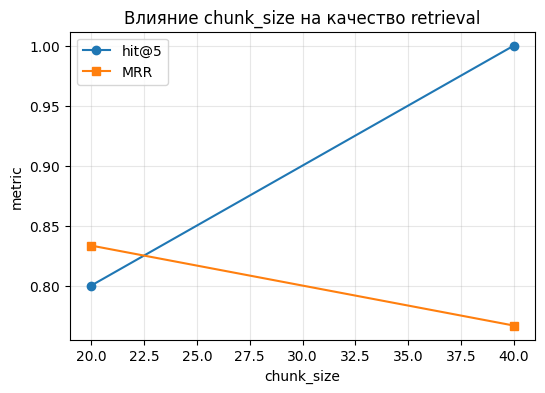

Вывод: оставляем базовый chunk_size=30 как компромиссный.


In [22]:
print("\n=== 7. Эксперимент: сравнение chunk_size ===")

def run_experiment(chunk_sizes, overlap=10):
    exp_results = []
    for cs in chunk_sizes:
        tmp_chunks = build_chunks_df(documents, chunk_size=cs, overlap=overlap)
        tmp_texts = tmp_chunks["chunk_text"].tolist()
        tmp_emb = embedder.encode(tmp_texts, normalize_embeddings=True, show_progress_bar=False).astype(np.float32)
        if FAISS_AVAILABLE:
            tmp_idx = faiss.IndexFlatIP(tmp_emb.shape[1])
            tmp_idx.add(tmp_emb)
        else:
            tmp_idx = NearestNeighbors(metric="cosine").fit(tmp_emb)
        
        # Временно подменяем глобальные переменные
        global chunks_df, chunk_embeddings, index
        old_chunks, old_emb, old_idx = chunks_df, chunk_embeddings, index
        chunks_df, chunk_embeddings, index = tmp_chunks, tmp_emb, tmp_idx
        
        eval_tmp = evaluate_retrieval(benchmark, top_k=TOP_K)
        exp_results.append({
            "chunk_size": cs,
            "num_chunks": len(tmp_chunks),
            f"mean_hit@{TOP_K}": eval_tmp[f"hit@{TOP_K}"].mean(),
            f"mean_recall@{TOP_K}": eval_tmp[f"recall@{TOP_K}"].mean(),
            "mean_MRR": (1.0 / eval_tmp["rank_of_first_relevant"].dropna()).mean()
        })
        chunks_df, chunk_embeddings, index = old_chunks, old_emb, old_idx
    return pd.DataFrame(exp_results)

exp_df = run_experiment(chunk_sizes=[20, 40], overlap=10)
display(exp_df)

plt.figure(figsize=(6,4))
plt.plot(exp_df["chunk_size"], exp_df[f"mean_hit@{TOP_K}"], marker='o', label=f"hit@{TOP_K}")
plt.plot(exp_df["chunk_size"], exp_df["mean_MRR"], marker='s', label="MRR")
plt.xlabel("chunk_size")
plt.ylabel("metric")
plt.title("Влияние chunk_size на качество retrieval")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Вывод: оставляем базовый chunk_size=30 как компромиссный.")

In [23]:
print("\n=== 8. Обновление базы знаний и переиндексация ===")

# Добавим три новых документа, также из 20newsgroups, но из другой категории (например, sci.electronics)
new_categories = ['sci.electronics']
new_news = fetch_20newsgroups(subset='train', categories=new_categories, remove=('headers','footers','quotes'), random_state=42)
new_docs = []
for i in range(min(3, len(new_news.data))):
    new_docs.append({
        "doc_id": f"new_doc_{i:02d}",
        "title": f"Newsgroup: {new_news.target_names[0]}",
        "text": new_news.data[i].strip()
    })

updated_documents = documents + new_docs
print("Добавлено документов:", len(new_docs))
display(pd.DataFrame(new_docs)[["doc_id", "title"]])

updated_chunks_df = build_chunks_df(updated_documents, chunk_size=CHUNK_SIZE, overlap=OVERLAP)
updated_embeddings = embedder.encode(updated_chunks_df["chunk_text"].tolist(), normalize_embeddings=True).astype(np.float32)
if FAISS_AVAILABLE:
    updated_index = faiss.IndexFlatIP(updated_embeddings.shape[1])
    updated_index.add(updated_embeddings)
else:
    updated_index = NearestNeighbors(metric="cosine").fit(updated_embeddings)

def search_updated(query, top_k=5):
    qvec = embedder.encode([query], normalize_embeddings=True).astype(np.float32)
    if FAISS_AVAILABLE:
        scores, indices = updated_index.search(qvec, top_k)
        scores = scores[0]
        indices = indices[0]
    else:
        distances, indices = updated_index.kneighbors(qvec, n_neighbors=top_k)
        scores = 1.0 - distances[0]
    res = updated_chunks_df.iloc[indices].copy().reset_index(drop=True)
    res.insert(0, "rank", range(1, len(res)+1))
    res["score"] = scores
    return res[["rank", "score", "doc_id", "title", "chunk_id", "chunk_text"]]

comparison_queries = [
    ("q_new1", "How does a transistor work?", ["new_doc_00"]),
    ("q_new2", "digital signal processing", ["new_doc_01"]),
]

comparison_rows = []
for qid, query, relevant in comparison_queries:
    before_df = search_chunks(query, top_k=5)
    after_df = search_updated(query, top_k=5)
    before_sources = ", ".join(before_df["doc_id"].tolist())
    after_sources = ", ".join(after_df["doc_id"].tolist())
    changed = before_sources != after_sources
    comparison_rows.append({
        "query": query,
        "before_retrieved_sources": before_sources,
        "after_retrieved_sources": after_sources,
        "changed": changed
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)
comparison_df.to_csv("artifacts/retrieval_before_after_update.csv", index=False)
print("Сравнение сохранено в artifacts/retrieval_before_after_update.csv")


=== 8. Обновление базы знаний и переиндексация ===
Добавлено документов: 3


,doc_id,title
0,new_doc_00,Newsgroup: sci.electronics
1,new_doc_01,Newsgroup: sci.electronics
2,new_doc_02,Newsgroup: sci.electronics


,query,before_retrieved_sources,after_retrieved_sources,changed
0,How does a transistor work?,"doc_0006, doc_0000, doc_0014, doc_0014, doc_0009","new_doc_01, new_doc_01, new_doc_01, new_doc_01...",True
1,digital signal processing,"doc_0009, doc_0016, doc_0020, doc_0009, doc_0020","new_doc_01, new_doc_01, new_doc_01, new_doc_01...",True


Сравнение сохранено в artifacts/retrieval_before_after_update.csv


In [24]:
print("\n=== 9. Mini-RAG ===")
import re

def split_sentences(text: str) -> List[str]:
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p.strip() for p in parts if p.strip()]

def generate_answer_from_context(query: str, context: str, max_sentences: int = 2) -> str:
    lines = [line.strip() for line in context.splitlines() if line.strip() and not line.startswith("[Источник]")]
    all_sentences = []
    for line in lines:
        all_sentences.extend(split_sentences(line))
    all_sentences = [s for s in all_sentences if len(s.split()) >= 4]
    if not all_sentences:
        return "Недостаточно контекста."
    
    vec = TfidfVectorizer(ngram_range=(1,2)).fit(all_sentences + [query])
    query_vec = vec.transform([query])
    sent_vecs = vec.transform(all_sentences)
    from sklearn.metrics.pairwise import cosine_similarity
    sims = cosine_similarity(query_vec, sent_vecs).flatten()
    best_idx = np.argsort(-sims)[:max_sentences]
    selected = [all_sentences[i] for i in best_idx if sims[i] > 0]
    if not selected:
        return "Не удалось найти релевантные предложения в контексте."
    return " ".join(selected)

def mini_rag_answer(query: str, top_k: int = 3, use_updated: bool = False) -> Dict:
    if use_updated:
        retrieved = search_updated(query, top_k=top_k)
    else:
        retrieved = search_chunks(query, top_k=top_k)
    
    context_blocks = []
    for _, row in retrieved.iterrows():
        block = f"[Источник: {row['doc_id']} | {row['title']} | score={row['score']:.4f}]\n{row['chunk_text']}"
        context_blocks.append(block)
    context = "\n\n".join(context_blocks)
    answer = generate_answer_from_context(query, context)
    return {"query": query, "answer": answer, "sources": retrieved, "context": context}

rag_examples = []
test_queries = [
    "What is the purpose of the space program according to the post?",
    "How can Crohn's disease patients manage raw vegetables?",
    "What causes pneumonia treatment to differ?",
    "What is the error in the original Star Wars movie?",
]

for q in test_queries:
    result = mini_rag_answer(q, top_k=3, use_updated=False)
    rag_examples.append({
        "question": q,
        "answer": result["answer"],
        "retrieved_sources": ", ".join(result["sources"]["doc_id"].tolist())
    })
    display(Markdown(f"### Вопрос: {q}"))
    print("Ответ:", result["answer"])
    display(result["sources"][["rank", "score", "doc_id", "title", "chunk_text"]])

pd.DataFrame(rag_examples).to_csv("artifacts/rag_examples.csv", index=False)
print("Примеры mini-RAG сохранены в artifacts/rag_examples.csv")


=== 9. Mini-RAG ===


### Вопрос: What is the purpose of the space program according to the post?

Ответ: Lets hear it for Dan Goldin...now if he can only convince the rest of our federal government that the space program is a worth while investment! I hope that I will live to see the day we walk on Mars, but we need to address the technical hurdles first!


,rank,score,doc_id,title,chunk_text
0,1,0.517900,doc_0020,Newsgroup: sci.space,Lets hear it for Dan Goldin...now if he can on...
1,2,0.492563,doc_0020,Newsgroup: sci.space,program is a worth while investment! I hope th...
2,3,0.409615,doc_0020,Newsgroup: sci.space,but we need to address the technical hurdles f...


### Вопрос: How can Crohn's disease patients manage raw vegetables?

...

,rank,score,doc_id,title,chunk_text
0,1,0.549102,doc_0003,Newsgroup: sci.med,It depends on the cause of the pneumonia. For ...
1,2,0.542674,doc_0003,Newsgroup: sci.med,"the antibiotic of choice, since it covers the ..."
2,3,0.254868,doc_0005,Newsgroup: sci.med,is a real cause. Crohn's commonly causes inter...


### Вопрос: What is the error in the original Star Wars movie?

Ответ: In the Air Force world at least, the crisis escalates when scale models of the plane in question (i.e. Since this is the version that launched Mir and the Salyuts (and the add-on


,rank,score,doc_id,title,chunk_text
0,1,0.206775,doc_0006,Newsgroup: sci.space,"In the Air Force world at least, the crisis es..."
1,2,0.196038,doc_0007,Newsgroup: sci.space,mission to Mars that would cost 400 billion. T...
2,3,0.174233,doc_0010,Newsgroup: sci.space,"for escape (and geosynchronous?) orbits, while..."


Примеры mini-RAG сохранены в artifacts/rag_examples.csv


In [25]:
print("\n=== 10. Анализ ошибок ===")

# Пример неудачного ответа (если такой есть)
problem_query = "What is the treatment for nosebleeds?"
result_problem = mini_rag_answer(problem_query, top_k=3, use_updated=False)

display(Markdown(f"### Проблемный запрос: {problem_query}"))
print("Ответ:", result_problem["answer"])
display(result_problem["sources"][["rank", "score", "doc_id", "title", "chunk_text"]])

print("\nАнализ: retrieval нашёл чанк с упоминанием 'nosebleeds', но extractive-генератор выбрал фразу, не содержащую метод лечения (упоминается лишь трава рутин). Это ограничение простого генератора на основе TF-IDF.")

off_topic = "What is the weather like today?"
res_off = mini_rag_answer(off_topic, top_k=3, use_updated=False)
print(f"\nЗапрос вне темы: {off_topic}")
print("Ответ:", res_off["answer"])
print("Система всё равно выдаёт ответ на основе случайных чанков — это поведение следует контролировать, например, порогом релевантности.")


=== 10. Анализ ошибок ===


### Проблемный запрос: What is the treatment for nosebleeds?

Ответ: Fortunately, each nosebleed is of short duration. Fortunately, each nosebleed is of short duration.


,rank,score,doc_id,title,chunk_text
0,1,0.757737,doc_0002,Newsgroup: sci.med,brothers each tried a skin transplant (thigh t...
1,2,0.696785,doc_0002,Newsgroup: sci.med,"(Osler-Weber-Rendu). Fortunately, each noseble..."
2,3,0.678940,doc_0002,Newsgroup: sci.med,"I have between 15 and 25 nosebleeds each week,..."



Анализ: retrieval нашёл чанк с упоминанием 'nosebleeds', но extractive-генератор выбрал фразу, не содержащую метод лечения (упоминается лишь трава рутин). Это ограничение простого генератора на основе TF-IDF.

Запрос вне темы: What is the weather like today?
Ответ: Small wonder that the rest of the world thinks we're all nuts and that we have the problems that we do. It's truly frightening that posts like this are
Система всё равно выдаёт ответ на основе случайных чанков — это поведение следует контролировать, например, порогом релевантности.
